# Lateness Risk Baseline BO Analysis

Analysis notebook for `BO_lateness_risk.py`. It expects results in `rl_bo_results/lateness_risk_baseline` by default.

In [53]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

CWD = Path.cwd().resolve()
if CWD.name == "RL":
    BASE_DIR = CWD
elif (CWD / "RL").exists():
    BASE_DIR = CWD / "RL"
elif (CWD / "BA-Simulation-Optimization" / "RL").exists():
    BASE_DIR = CWD / "BA-Simulation-Optimization" / "RL"
else:
    BASE_DIR = CWD

RESULT_DIR = BASE_DIR / "lateness_risk_bo_results" / "lateness_risk_baseline_50"
TRIALS_PATH = RESULT_DIR / "lateness_risk_trials.csv"
REPLICATIONS_PATH = RESULT_DIR / "lateness_risk_replications.csv"
CONFIG_PATH = RESULT_DIR / "lateness_risk_config.json"
BEST_PATH = RESULT_DIR / "lateness_risk_best_parameters.json"

RESULT_DIR

WindowsPath('C:/Workspace ZHAW/6. Semester/BA/BA-Simulation-Optimization/RL/lateness_risk_bo_results/lateness_risk_baseline_50')

In [54]:
def read_json(path):
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))

def valid_rows(df):
    if df.empty or "error" not in df.columns:
        return df
    return df[df["error"].fillna("") == ""].copy()

def coerce_numeric(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

config = read_json(CONFIG_PATH)
best = read_json(BEST_PATH)

trials = pd.read_csv(TRIALS_PATH) if TRIALS_PATH.exists() else pd.DataFrame()
replications = pd.read_csv(REPLICATIONS_PATH) if REPLICATIONS_PATH.exists() else pd.DataFrame()

trial_numeric = [
    "trial_index", "risk_t1", "risk_window", "risk_t2", "objective_mean",
    "objective_std", "best_objective_so_far", "total_reward_mean",
    "total_reward_std", "late_order_fraction_mean", "time_in_system_mean",
    "wip_mean", "n_valid_replications",
]
rep_numeric = [
    "trial_index", "replication", "objective_value", "total_reward",
    "late_order_fraction", "time_in_system_mean", "wip_mean", "n_orders_late",
    "n_orders_completed", "risk_t1", "risk_window", "risk_t2",
]
trials = coerce_numeric(trials, trial_numeric)
replications = coerce_numeric(valid_rows(replications), rep_numeric)

print(f"Trials: {len(trials)}")
print(f"Replications: {len(replications)}")
best

Trials: 50
Replications: 1500


{'objective': 'Ax minimizes -mean(total_reward); lower objective is better.',
 'best_trial_index': 21,
 'best_objective': -362.8333333333333,
 'best_total_reward_mean': 362.8333333333333,
 'best_late_order_fraction_mean': 0.41968714741059715,
 'best_parameters': {'risk_t1': 175.76447689852776,
  'risk_window': 758.0036248230721},
 'best_risk_t2': 933.7681017215998,
 'n_valid_replications': 30}

## Configuration

In [55]:
pd.Series(config)

experiment                                     lateness_risk_baseline_bo
objective              Ax minimizes -mean(total_reward); lower object...
baseline_rule                                      Highest Lateness Risk
fixed_action                                                           3
n_trials                                                              50
n_replications                                                        30
run_duration                                                        1440
rate_multiplier                                                      0.9
base_seed                                                          12345
seed_step                                                           1000
bo_random_seed                                                     24680
eval_seeds             [312345, 313345, 314345, 315345, 316345, 31734...
station_capacities     {'preparation_capacity': 1, 'sorting_capacity'...
parameter_bounds       {'risk_t1': [40.0, 360.0], '

## Trial Overview

In [56]:
if trials.empty:
    print(f"No trial results found at {TRIALS_PATH}")
else:
    display(trials.sort_values("objective_mean").head(10))

,trial_index,risk_t1,risk_window,risk_t2,objective_mean,objective_std,best_objective_so_far,total_reward_mean,total_reward_std,late_order_fraction_mean,time_in_system_mean,wip_mean,n_valid_replications
24,24,175.752147,1800.000000,1975.752147,-362.833333,321.905649,-362.833333,362.833333,321.905649,0.419687,343.259402,134.822994,30
28,28,176.268027,1306.872760,1483.140787,-362.833333,319.574834,-362.833333,362.833333,319.574834,0.419693,343.213999,134.822994,30
21,21,175.764477,758.003625,933.768102,-362.833333,321.905649,-362.833333,362.833333,321.905649,0.419687,343.259402,134.822994,30
44,44,175.214912,120.000000,295.214912,-362.833333,318.980821,-362.833333,362.833333,318.980821,0.419669,343.296218,134.822994,30
43,43,172.908568,1073.564757,1246.473325,-359.500000,317.604585,-362.833333,359.500000,317.604585,0.420247,343.262822,134.822994,30
11,11,172.881694,120.000000,292.881694,-359.500000,317.604585,-359.500000,359.500000,317.604585,0.420247,343.268033,134.822994,30
10,10,171.351314,1800.000000,1971.351314,-354.833333,328.185932,-354.833333,354.833333,328.185932,0.421101,343.263470,134.822994,30
32,32,172.006410,649.832691,821.839101,-354.833333,325.379045,-362.833333,354.833333,325.379045,0.421090,343.289324,134.822994,30
27,27,181.474036,671.672263,853.146298,-350.833333,321.378183,-362.833333,350.833333,321.378183,0.421808,343.170967,134.822994,30
13,13,179.342236,1106.625830,1285.968066,-350.166667,314.643431,-359.500000,350.166667,314.643431,0.421889,343.152814,134.822994,30


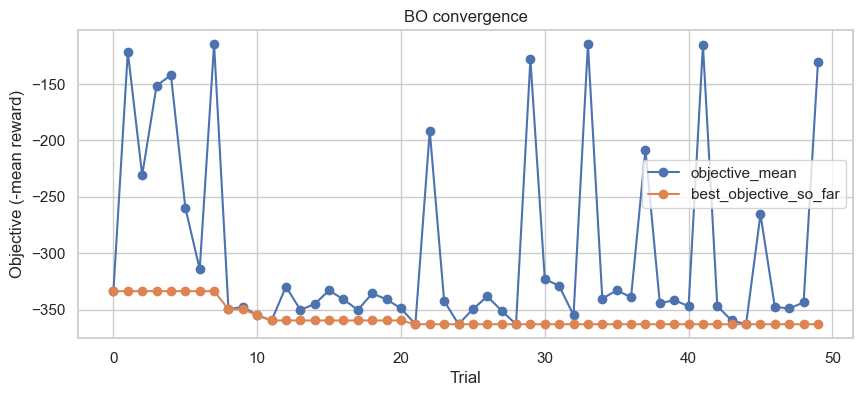

In [57]:
if not trials.empty:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(trials["trial_index"], trials["objective_mean"], marker="o", label="objective_mean")
    ax1.plot(trials["trial_index"], trials["best_objective_so_far"], marker="o", label="best_objective_so_far")
    ax1.set_xlabel("Trial")
    ax1.set_ylabel("Objective (-mean reward)")
    ax1.legend(loc="best")
    ax1.set_title("BO convergence")
    plt.show()

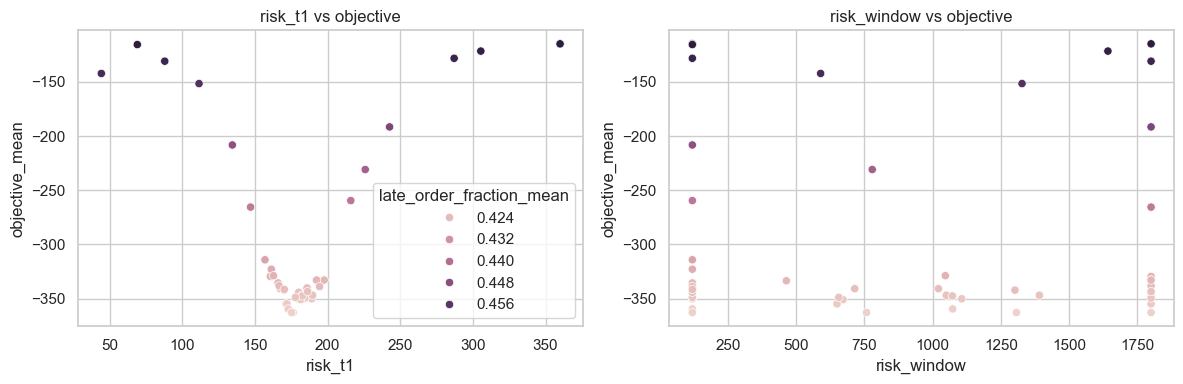

In [58]:
if not trials.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(data=trials, x="risk_t1", y="objective_mean", hue="late_order_fraction_mean", ax=axes[0])
    sns.scatterplot(data=trials, x="risk_window", y="objective_mean", hue="late_order_fraction_mean", ax=axes[1], legend=False)
    axes[0].set_title("risk_t1 vs objective")
    axes[1].set_title("risk_window vs objective")
    plt.tight_layout()
    plt.show()

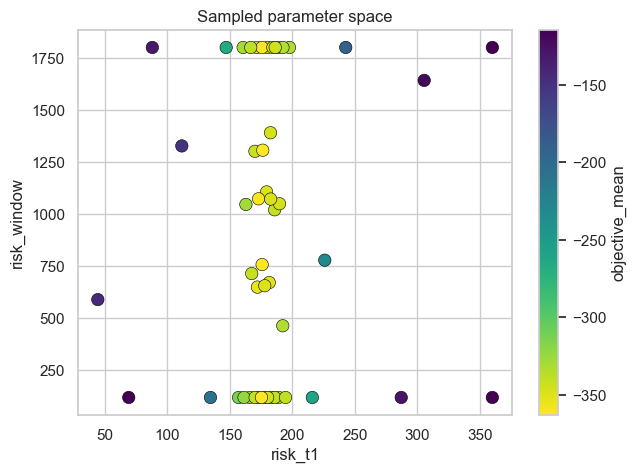

In [59]:
if not trials.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        trials["risk_t1"],
        trials["risk_window"],
        c=trials["objective_mean"],
        s=80,
        cmap="viridis_r",
        edgecolor="black",
        linewidth=0.4,
    )
    ax.set_xlabel("risk_t1")
    ax.set_ylabel("risk_window")
    ax.set_title("Sampled parameter space")
    fig.colorbar(sc, ax=ax, label="objective_mean")
    plt.show()

## Best Trial Replications

In [60]:
if trials.empty or replications.empty:
    print("No replication data available.")
else:
    best_trial_index = int(trials.sort_values("objective_mean").iloc[0]["trial_index"])
    best_reps = replications[replications["trial_index"] == best_trial_index].copy()
    print(f"Best trial index: {best_trial_index}")
    display(best_reps[["replication", "eval_seed", "total_reward", "late_order_fraction", "time_in_system_mean", "wip_mean"]].describe())

Best trial index: 24


,replication,eval_seed,total_reward,late_order_fraction,time_in_system_mean,wip_mean
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,14.500000,326845.000000,362.833333,0.419687,343.259402,134.822994
std,8.803408,8803.408431,321.905649,0.057327,28.748760,16.093441
min,0.000000,312345.000000,-329.000000,0.272085,271.253733,101.014745
25%,7.250000,319595.000000,141.250000,0.400534,330.485077,125.232214
50%,14.500000,326845.000000,382.000000,0.419335,344.665838,133.948236
75%,21.750000,334095.000000,487.250000,0.457998,361.910219,147.554849
max,29.000000,341345.000000,1203.000000,0.545098,404.811860,175.869539


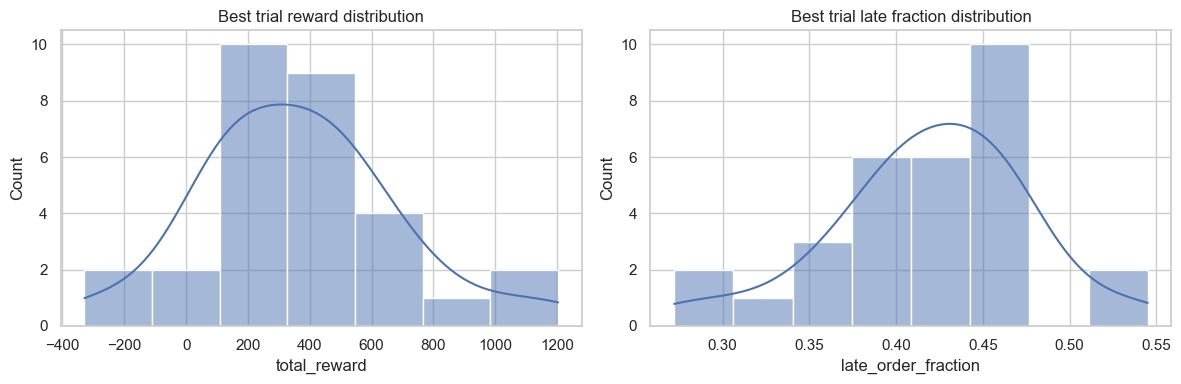

In [61]:
if not trials.empty and not replications.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(best_reps["total_reward"], kde=True, ax=axes[0])
    sns.histplot(best_reps["late_order_fraction"], kde=True, ax=axes[1])
    axes[0].set_title("Best trial reward distribution")
    axes[1].set_title("Best trial late fraction distribution")
    plt.tight_layout()
    plt.show()

## Export Summary

In [62]:
if not trials.empty:
    summary_cols = [
        "trial_index", "risk_t1", "risk_window", "risk_t2", "objective_mean",
        "total_reward_mean", "total_reward_std", "late_order_fraction_mean",
        "n_valid_replications",
    ]
    display(trials.sort_values("objective_mean")[summary_cols].head(15))

,trial_index,risk_t1,risk_window,risk_t2,objective_mean,total_reward_mean,total_reward_std,late_order_fraction_mean,n_valid_replications
24,24,175.752147,1800.000000,1975.752147,-362.833333,362.833333,321.905649,0.419687,30
28,28,176.268027,1306.872760,1483.140787,-362.833333,362.833333,319.574834,0.419693,30
21,21,175.764477,758.003625,933.768102,-362.833333,362.833333,321.905649,0.419687,30
44,44,175.214912,120.000000,295.214912,-362.833333,362.833333,318.980821,0.419669,30
43,43,172.908568,1073.564757,1246.473325,-359.500000,359.500000,317.604585,0.420247,30
11,11,172.881694,120.000000,292.881694,-359.500000,359.500000,317.604585,0.420247,30
10,10,171.351314,1800.000000,1971.351314,-354.833333,354.833333,328.185932,0.421101,30
32,32,172.006410,649.832691,821.839101,-354.833333,354.833333,325.379045,0.421090,30
27,27,181.474036,671.672263,853.146298,-350.833333,350.833333,321.378183,0.421808,30
13,13,179.342236,1106.625830,1285.968066,-350.166667,350.166667,314.643431,0.421889,30
